<div class="usecase-title">Urban Bike-Sharing Demand Forecast with a GCN-LSTM Hybrid Model</div>

<div class="usecase-authors"><b>Authored by: </b> Nithin Garmidi</div>

<div class="usecase-duration"><b>Duration:</b> 90 mins</div>

<div class="usecase-level-skill">
    <div class="usecase-level"><b>Level: </b>Intermediate</div>
    <div class="usecase-skill"><b>Pre-requisite Skills: </b>Python, Pandas, NumPy, PyTorch, Matplotlib</div>
</div>

<h2 class="usecase-section-header">Scenario</h2>
<p>
A bike-share network has hundreds of docking stations across a city. Some run out of bikes during rush hour, others fill up so riders can't drop one off. Trucks are driven around to move bikes from station to station but only after a problem has already happened and it’s slow and expensive. If we can predict how many bikes each station will need in the next few hours, crews can move them ahead of time, instead of chasing problems.
</p>

<h2 class="usecase-section-header">User Story</h2>
<p>As a data scientist on the operations team. I get the trip and station data, do analysis on usage trends over time and location, and create models to predict pickups at each station hours in advance. Those predictions are used by the riders to reach the locations well in advance.</p>

<h2 class="usecase-section-header">What this use case will teach you</h2>
<ul>
<li>Ingest monthly bike-share trip data from a public S3 bucket</li>
<li>Convert millions of trips into a table of hourly demand (1 row per hour, 1 column per station).</li>
<li>Look for time-of-day and seasonal trends in the data.</li>
<li>To construct a station graph, connect each station to its nearest neighbours.</li>
<li>Implement a Graph Convolutional Network (GCN) layer</li>
<li>Combine that GCN with an LSTM so the model takes advantage of both where and when.</li>
<li>We compare the deep model with a calendar based baseline and a plain LSTM.</li>
<li>Plot errors by station to see which stations the model is struggling with.</li>
</ul>

<h1 class="usecase-section-header">Introduction</h1>

<p>Predicting bike-share demand a few hours ahead is hard. Classic models like ARIMA only look at one station, and a plain LSTM adds memory but still does not know which stations sit next to each other. Neighbouring stations share the same commuters and weather, so their demand tends to move together. A small Graph Convolutional Network (GCN) can pass information between connected stations, and an LSTM on top of it captures the time pattern.</p>

<p>In this notebook we build a GCN + LSTM model that predicts hourly pickups 1, 3 and 6 hours ahead, and compare it to two simpler baselines. The GCN layer is written by hand in PyTorch, so we don't need any graph-learning libraries.</p>

<h3 class="usecase-section-header">Dataset</h3>
<p>We use the <a href="https://capitalbikeshare.com/system-data">Capital Bikeshare</a> trip history from Washington, DC. There is one CSV per month with one row per trip (start/end station, coordinates, timestamps). We pull 6 months: April–September 2024.</p>

**References:**
- Capital Bikeshare system data: <a href="https://capitalbikeshare.com/system-data">https://capitalbikeshare.com/system-data</a>

<h2 class="usecase-section-header">Setup and Imports</h2>

<p>Install and import the libraries we need. We also create a <code>data/</code> folder to hold downloads and processed files.</p>

<h3 class="usecase-subsection-header">Install Packages</h3>

In [1]:
pip install -q pandas numpy matplotlib seaborn requests tqdm pyarrow torch

<h3 class="usecase-subsection-header">Import Packages</h3>

In [2]:
import io
import math
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import requests
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROC_DIR = DATA_DIR / "processed"
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR.mkdir(parents=True, exist_ok=True)

print("Project dir:", PROJECT_DIR)

Using device: cpu
Project dir: /content


<h2 class="usecase-section-header">Data Download</h2>

<p>Capital Bikeshare publishes one ZIP per month on a public S3 bucket. We grab 6 months (April–September 2024), about <b>678 MB</b> in total, and save them under <code>data/raw/</code>.</p>

<h3 class="usecase-subsection-header">Download Trip Data</h3>

<p>Loop over the 6 months, fetch each ZIP from S3, and extract the CSV. Months that are already on disk are skipped.</p>

In [3]:
MONTHS = ["202404", "202405", "202406", "202407", "202408", "202409"]
BASE_URL = "https://s3.amazonaws.com/capitalbikeshare-data/{ym}-capitalbikeshare-tripdata.zip"


def download_month(ym):
    """Download and unzip one month of trip data. Returns the CSV path."""
    csv_path = RAW_DIR / f"{ym}-capitalbikeshare-tripdata.csv"
    if csv_path.exists():
        return csv_path

    url = BASE_URL.format(ym=ym)
    print(f"Downloading {url}")
    resp = requests.get(url, timeout=120)
    resp.raise_for_status()

    with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
        members = [m for m in zf.namelist() if m.endswith(".csv") and not m.startswith("__MACOSX")]
        zf.extract(members[0], RAW_DIR)
        extracted = RAW_DIR / members[0]
        if extracted != csv_path:
            extracted.rename(csv_path)
    return csv_path


csv_paths = [download_month(ym) for ym in tqdm(MONTHS, desc="Downloading months")]

print(f"Have {len(csv_paths)} monthly CSVs:")
for p in csv_paths:
    print(f"  {p.name}  ({p.stat().st_size / 1e6:.1f} MB)")

Have 6 monthly CSVs:
  202404-capitalbikeshare-tripdata.csv  (94.9 MB)
  202405-capitalbikeshare-tripdata.csv  (99.4 MB)
  202406-capitalbikeshare-tripdata.csv  (116.7 MB)
  202407-capitalbikeshare-tripdata.csv  (116.6 MB)
  202408-capitalbikeshare-tripdata.csv  (120.7 MB)
  202409-capitalbikeshare-tripdata.csv  (129.4 MB)


<h2 class="usecase-section-header">Loading, EDA, and Preprocessing</h2>

<p>Load the monthly CSVs, look at the data, and reshape it into an hourly demand table of shape <code>[hours, stations]</code>. The raw data has ~3.46 M trips across ~790 stations; after cleaning we keep ~2.85 M trips at the top 100 busiest stations (~47.7% of all trips).</p>

<h3 class="usecase-subsection-header">Load Trip CSVs</h3>

<p>Read the 6 monthly CSVs into a single DataFrame and keep only the columns we care about (timestamp, station ID, station name, coordinates).</p>

In [4]:
USECOLS = ["started_at", "start_station_id", "start_station_name", "start_lat", "start_lng"]

frames = [pd.read_csv(p, usecols=USECOLS, parse_dates=["started_at"]) for p in csv_paths]
trips = pd.concat(frames, ignore_index=True)

print("Total trips loaded:", len(trips))
trips.head()

Total trips loaded: 3459005


,started_at,start_station_name,start_station_id,start_lat,start_lng
0,2024-04-29 17:03:15,Jones Branch & Westbranch Dr,32206.0,38.931911,-77.219261
1,2024-04-19 17:36:14,14th & Otis Pl NW,31131.0,38.934405,-77.032687
2,2024-04-06 10:18:39,14th & Otis Pl NW,31131.0,38.934405,-77.032687
3,2024-04-01 13:24:00,14th & Otis Pl NW,31131.0,38.934405,-77.032687
4,2024-04-01 13:24:14,14th & Otis Pl NW,31131.0,38.934405,-77.032687


<h3 class="usecase-subsection-header">Clean Trip Records</h3>

<p>Drop trips with missing station IDs, coordinates, or timestamps. Then print how many trips, how many stations, and what the date range looks like.</p>

In [5]:
trips = trips.dropna(subset=["start_station_id", "start_lat", "start_lng", "started_at"])
trips["start_station_id"] = trips["start_station_id"].astype(str)

print("After cleaning:", len(trips), "trips")
print("Date range:", trips["started_at"].min(), "→", trips["started_at"].max())
print("Unique stations:", trips["start_station_id"].nunique())

After cleaning: 2846841 trips
Date range: 2024-04-01 00:02:19 → 2024-09-30 23:56:49.220000
Unique stations: 790


<h3 class="usecase-subsection-header">Daily and Hourly Trip Patterns</h3>

<p>Two quick charts: total trips per day across the whole window, and total trips by hour of the day.</p>

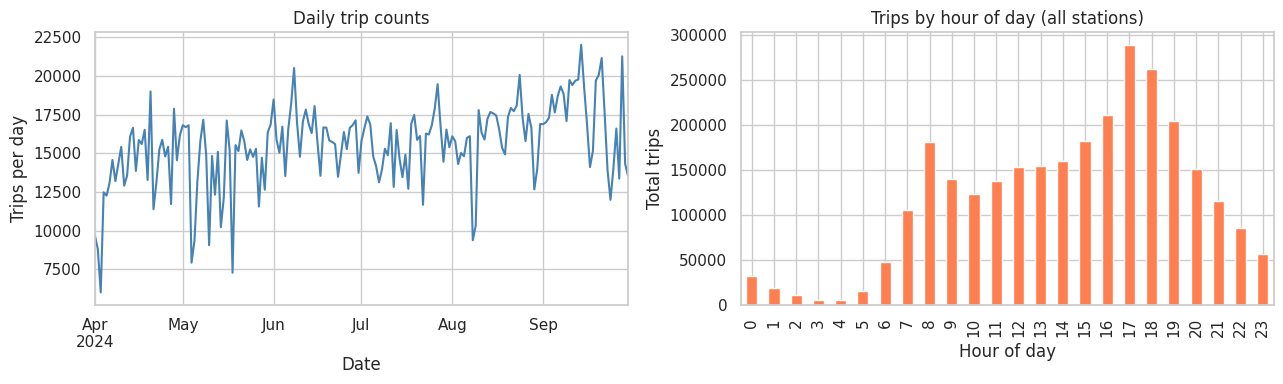

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

trips_per_day = trips.set_index("started_at").resample("D").size()
trips_per_day.plot(ax=axes[0], color="steelblue")
axes[0].set_title("Daily trip counts")
axes[0].set_ylabel("Trips per day")
axes[0].set_xlabel("Date")

trips_by_hour = trips.assign(hour=trips["started_at"].dt.hour).groupby("hour").size()
trips_by_hour.plot.bar(ax=axes[1], color="coral")
axes[1].set_title("Trips by hour of day (all stations)")
axes[1].set_xlabel("Hour of day")
axes[1].set_ylabel("Total trips")

plt.tight_layout()
plt.show()

**Observations:**

- Daily trips sit between ~15,000 and ~25,000, with a summer bump and more rides on weekdays.
- Demand spikes around 8 AM and again, bigger, around 5–6 PM — the classic commuter pattern.
- These repeating patterns are strong enough that a calendar-based baseline will be hard to beat.

<h3 class="usecase-subsection-header">Select Top Stations</h3>

<p>Rank stations by trip count and keep the top <code>N_STATIONS = 100</code>. We also grab each station's median latitude and longitude so we can build the graph later.</p>

In [7]:
N_STATIONS = 100

station_counts = (
    trips.groupby("start_station_id").size().sort_values(ascending=False)
)
top_stations = station_counts.head(N_STATIONS).index.tolist()

stations = (
    trips[trips["start_station_id"].isin(top_stations)]
    .groupby("start_station_id")
    .agg(
        name=("start_station_name", lambda s: s.mode().iat[0]),
        lat=("start_lat", "median"),
        lng=("start_lng", "median"),
        trips=("started_at", "size"),
    )
    .loc[top_stations]
    .reset_index()
    .rename(columns={"start_station_id": "station_id"})
)

print(f"Kept top {N_STATIONS} stations covering "
      f"{stations['trips'].sum() / station_counts.sum():.1%} of trips.")
stations.head()

Kept top 100 stations covering 47.7% of trips.


,station_id,name,lat,lng,trips
0,31623.0,Columbus Circle / Union Station,38.896960,-77.004930,30539
1,31229.0,New Hampshire Ave & T St NW,38.915544,-77.038252,28206
2,31201.0,15th & P St NW,38.909801,-77.034427,24611
3,31101.0,14th & V St NW,38.917764,-77.032096,23479
4,31603.0,1st & M St NE,38.905697,-77.005483,23126


**Observations:**

- The busiest station (Columbus Circle / Union Station) had ~30,500 pickups, more than 2x the average.
- The top 100 stations cover ~47.7% of all trips; the remaining ~690 stations form a long tail.
- Keeping the top 100 makes training fast while still covering most of the demand.

<h3 class="usecase-subsection-header">Aggregate to Hourly Demand</h3>

<p>Count pickups per (hour, station) and pivot into a table of shape <code>[hours, stations]</code>. Hours with no pickups become zero. The result is cached as Parquet so reloads are instant.</p>

In [8]:
demand_path = PROC_DIR / "hourly_demand.parquet"

if demand_path.exists():
    demand = pd.read_parquet(demand_path)
    print("Loaded cached hourly demand:", demand.shape)
else:
    sub = trips[trips["start_station_id"].isin(top_stations)].copy()
    sub["hour"] = sub["started_at"].dt.floor("h")
    pivot = sub.groupby(["hour", "start_station_id"]).size().unstack(fill_value=0)
    full_index = pd.date_range(pivot.index.min(), pivot.index.max(), freq="h")
    demand = pivot.reindex(index=full_index, columns=top_stations, fill_value=0)
    demand.index.name = "hour"
    demand.to_parquet(demand_path)
    print("Built and cached hourly demand:", demand.shape)

print("Time range:", demand.index.min(), "→", demand.index.max())
print("Mean hourly pickups per station:", demand.values.mean().round(2))
demand.iloc[:5, :5]

Built and cached hourly demand: (4392, 100)
Time range: 2024-04-01 00:00:00 → 2024-09-30 23:00:00
Mean hourly pickups per station: 3.09


start_station_id,31623.0,31229.0,31201.0,31101.0,31603.0
hour,,,,,
2024-04-01 00:00:00,0,0,1,3,0
2024-04-01 01:00:00,0,0,0,0,1
2024-04-01 02:00:00,2,0,0,0,0
2024-04-01 03:00:00,0,0,0,0,0
2024-04-01 04:00:00,0,0,0,0,0


---

<h2 class="usecase-section-header">Station Graph Construction</h2>

<p>Each station is a node of a graph. We link each station to its 8 nearest neighbours (where "nearest" is in real-world distance on the map). Closer stations get a stronger link, farther stations get a weaker one. We then scale the connections so the GCN can use them. With 100 stations we end up with 482 connections in total (about 9-10 neighbours per station).</p>

<h3 class="usecase-subsection-header">Build kNN Adjacency</h3>

<p>Compute pairwise distance between all stations, keep each station's 8 closest neighbours with Gaussian edge weights, and build the normalised adjacency the GCN expects.</p>

In [9]:
def haversine_matrix(lats, lngs):
    """Pairwise great-circle distance in km."""
    R = 6371.0
    lat = np.radians(lats)[:, None]
    lng = np.radians(lngs)[:, None]
    dlat = lat - lat.T
    dlng = lng - lng.T
    a = np.sin(dlat / 2) ** 2 + np.cos(lat) * np.cos(lat.T) * np.sin(dlng / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))


def build_knn_adjacency(stations_df, k=8):
    """Build a symmetric kNN graph with Gaussian edge weights."""
    dist = haversine_matrix(stations_df["lat"].values, stations_df["lng"].values)
    np.fill_diagonal(dist, np.inf)

    n = dist.shape[0]
    nn_idx = np.argsort(dist, axis=1)[:, :k]
    sigma = np.median(np.take_along_axis(dist, nn_idx, axis=1))

    A = np.zeros_like(dist)
    for i in range(n):
        for j in nn_idx[i]:
            A[i, j] = math.exp(-(dist[i, j] ** 2) / (sigma ** 2))
    A = np.maximum(A, A.T)

    # Symmetric normalization: A_norm = D^-1/2 (A + I) D^-1/2
    A_tilde = A + np.eye(n)
    d_inv_sqrt = np.power(A_tilde.sum(axis=1), -0.5)
    A_norm = (d_inv_sqrt[:, None] * A_tilde) * d_inv_sqrt[None, :]
    return A, A_norm


A, A_norm = build_knn_adjacency(stations, k=8)
print(f"Adjacency: shape={A.shape}, edges={(A > 0).sum() // 2}, mean degree={(A > 0).sum(axis=1).mean():.1f}")

A_norm_t = torch.tensor(A_norm, dtype=torch.float32, device=DEVICE)

Adjacency: shape=(100, 100), edges=482, mean degree=9.6


**Observations:**

- The k=8 adjacency has 482 undirected edges and ~9.6 neighbours per station — slightly more than k=8 because symmetrising (`A = max(A, A.T)`) adds extra links.
- Using the median neighbour distance as \( \sigma \) spreads edge weights nicely across the 0–1 range.

<h3 class="usecase-subsection-header">Visualize Station Graph</h3>

<p>Plot the stations on a lat/lng scatter plot and draw the kNN edges as thin grey lines.</p>

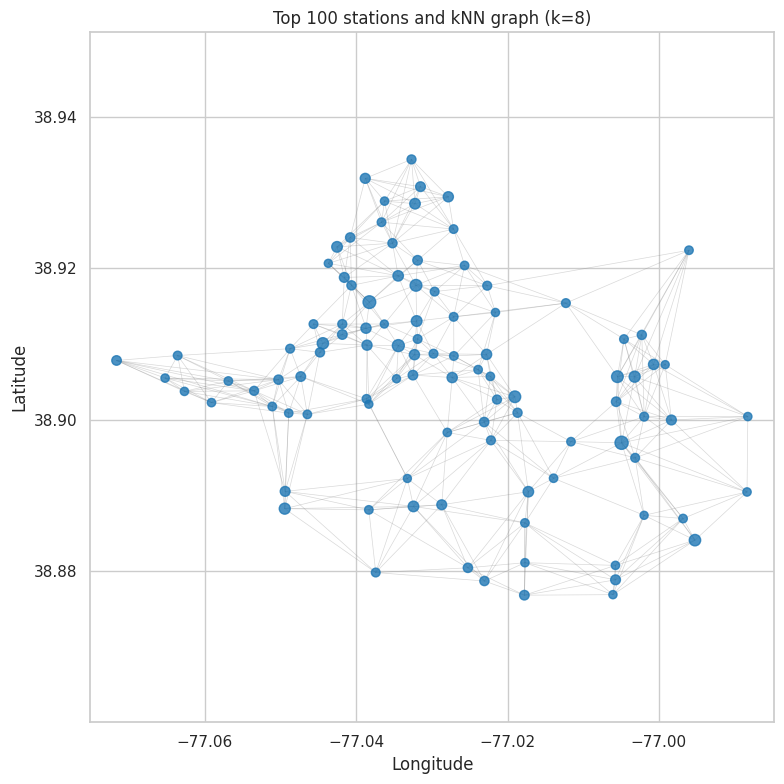

In [10]:
fig, ax = plt.subplots(figsize=(8, 8))

n = len(stations)
for i in range(n):
    for j in range(i + 1, n):
        if A[i, j] > 0:
            ax.plot(
                [stations.iloc[i]["lng"], stations.iloc[j]["lng"]],
                [stations.iloc[i]["lat"], stations.iloc[j]["lat"]],
                color="grey", alpha=0.3, linewidth=0.5, zorder=1,
            )

ax.scatter(
    stations["lng"], stations["lat"],
    s=stations["trips"] / stations["trips"].max() * 80 + 10,
    color="#1f77b4", alpha=0.8, zorder=2,
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Top 100 stations and kNN graph (k=8)")
ax.set_aspect("equal", adjustable="datalim")
plt.tight_layout()
plt.show()

**Observations:**

- The graph clusters tightly around the downtown DC core where stations sit close together.
- Stations further out in Virginia and Maryland have longer edges and lower weights. i.e, fewer neighbours nearby.
- This is what we want for a GCN: dense local links downtown, sparser long-range links outside.

---

<h2 class="usecase-section-header">Train/Val/Test Split and Sliding Windows</h2>

<p>We split by time so the model only sees the past. With 4,392 hours of data the 70/15/15 split gives 3,074 train / 658 val / 660 test hours. Each window uses the last <code>T_in=12</code> hours of demand at all 100 stations as input, and predicts demand at <code>t+1</code>, <code>t+3</code>, and <code>t+6</code>.</p>

<p>We z-score each station using training-set statistics so busy and quiet stations contribute fairly to the loss, and undo the z-score before reporting RMSE / MAE.</p>

<h3 class="usecase-subsection-header">Build Sliding Windows</h3>

<p>Z-score per station, slide a 12-hour window across the timeline, and stack targets for t+1, t+3, and t+6. Wrap the arrays in a PyTorch <code>Dataset</code> and <code>DataLoader</code>.</p>

In [11]:
T_IN = 12
HORIZONS = [1, 3, 6]
H_MAX = max(HORIZONS)

values = demand.values.astype(np.float32)
T, N = values.shape
print("Demand tensor:", values.shape)

n_train = int(T * 0.70)
n_val = int(T * 0.15)
n_test = T - n_train - n_val
print(f"Train hours: {n_train} | Val hours: {n_val} | Test hours: {n_test}")

# Z-score using train stats only to avoid leakage.
mu = values[:n_train].mean(axis=0)
sd = values[:n_train].std(axis=0) + 1e-6
values_z = (values - mu) / sd


def build_windows(arr_z, t_start, t_end):
    """Slide a 12-hour window over arr_z and stack targets at t+1, t+3, t+6."""
    Xs, Ys = [], []
    for t in range(t_start, t_end - H_MAX):
        if t - T_IN < 0:
            continue
        Xs.append(arr_z[t - T_IN : t])
        Ys.append(np.stack([arr_z[t + h - 1] for h in HORIZONS], axis=0))
    return np.stack(Xs), np.stack(Ys)


X_tr, Y_tr = build_windows(values_z, T_IN, n_train)
X_va, Y_va = build_windows(values_z, n_train, n_train + n_val)
X_te, Y_te = build_windows(values_z, n_train + n_val, T)

print("X_train:", X_tr.shape, "Y_train:", Y_tr.shape)
print("X_val:  ", X_va.shape, "Y_val:  ", Y_va.shape)
print("X_test: ", X_te.shape, "Y_test: ", Y_te.shape)


def make_loader(X, Y, shuffle):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32),
                       torch.tensor(Y, dtype=torch.float32))
    return DataLoader(ds, batch_size=32, shuffle=shuffle)


loader_tr = make_loader(X_tr, Y_tr, shuffle=True)
loader_va = make_loader(X_va, Y_va, shuffle=False)
loader_te = make_loader(X_te, Y_te, shuffle=False)

Demand tensor: (4392, 100)
Train hours: 3074 | Val hours: 658 | Test hours: 660
X_train: (3056, 12, 100) Y_train: (3056, 3, 100)
X_val:   (652, 12, 100) Y_val:   (652, 3, 100)
X_test:  (654, 12, 100) Y_test:  (654, 3, 100)


---

<h2 class="usecase-section-header">Baselines</h2>

<p>We set up two simpler models to compare against:</p>

<ul>
<li><b>Historical Average (HA):</b> for each station and each (day-of-week, hour-of-day) slot, predict the training-set average. A pure calendar lookup, but a strong one when demand is this periodic.</li>
<li><b>LSTM (per-station):</b> a shared 2-layer LSTM run independently on each station's own history. No spatial info.</li>
</ul>

<h3 class="usecase-subsection-header">Metrics Helpers</h3>

<p>Tiny helpers for RMSE, MAE, and MAPE, plus one to undo the z-score so we can report errors in real trips per hour.</p>

In [12]:
def metrics(y_true, y_pred):
    """RMSE, MAE, and MAPE between two arrays of equal shape."""
    err = y_true - y_pred
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae = float(np.mean(np.abs(err)))
    # Floor the denominator at 1 to keep MAPE finite when actuals are 0.
    denom = np.where(np.abs(y_true) < 1.0, 1.0, np.abs(y_true))
    mape = float(np.mean(np.abs(err) / denom) * 100)
    return {"RMSE": rmse, "MAE": mae, "MAPE%": mape}


def per_horizon_metrics(y_true, y_pred, horizons=HORIZONS):
    """One row of metrics per forecast horizon."""
    rows = []
    for i, h in enumerate(horizons):
        row = metrics(y_true[:, i], y_pred[:, i])
        row["horizon_h"] = h
        rows.append(row)
    return pd.DataFrame(rows)[["horizon_h", "RMSE", "MAE", "MAPE%"]]


def to_original(values_z):
    """Undo per-station z-score so errors are in real trips/hour."""
    return values_z * sd + mu

<h3 class="usecase-subsection-header">Historical Average Baseline</h3>

<p>For each (station, day-of-week, hour) bucket, predict the average demand from the training set. This is the calendar baseline we need to beat.</p>

In [13]:
# Average pickups for every (day-of-week, hour-of-day) bucket in training.
train_df = demand.iloc[:n_train]
ha_table = (
    train_df.assign(dow=train_df.index.dayofweek, hod=train_df.index.hour)
    .groupby(["dow", "hod"])
    .mean()
)


def ha_predict_for_range(t_start, t_end):
    """Look up the (dow, hod) average for every test window."""
    preds, trues = [], []
    for t in range(t_start, t_end - H_MAX):
        if t - T_IN < 0:
            continue
        pred_h, true_h = [], []
        for h in HORIZONS:
            ts = demand.index[t + h - 1]
            pred_h.append(ha_table.loc[(ts.dayofweek, ts.hour)].values.astype(np.float32))
            true_h.append(values[t + h - 1])
        preds.append(np.stack(pred_h))
        trues.append(np.stack(true_h))
    return np.stack(preds), np.stack(trues)


ha_pred_te, ha_true_te = ha_predict_for_range(n_train + n_val, T)
print("HA test predictions shape:", ha_pred_te.shape)
ha_results = per_horizon_metrics(ha_true_te, ha_pred_te)
ha_results.insert(0, "model", "HistoricalAvg")
ha_results

HA test predictions shape: (654, 3, 100)


,model,horizon_h,RMSE,MAE,MAPE%
0,HistoricalAvg,1,2.669157,1.720789,63.304317
1,HistoricalAvg,3,2.672812,1.723594,63.293106
2,HistoricalAvg,6,2.671236,1.722107,63.406956


**Observations:**

- All three horizons land at almost the same RMSE (**2.67**) and MAE (**1.72**) — naturally, a calendar lookup does not care how far ahead you ask.
- This is the line the deep models have to clear.

<h3 class="usecase-subsection-header">LSTM Baseline Model</h3>

<p>A 2-layer LSTM applied to each station's demand history independently. A linear head turns the last hidden state into 3 predictions (t+1, t+3, t+6). No spatial signal — just memory.</p>

In [14]:
class StationLSTM(nn.Module):
    """Shared 2-layer LSTM applied independently to each station's history."""

    def __init__(self, hidden=32, n_horizons=len(HORIZONS), num_layers=2, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1, hidden_size=hidden, num_layers=num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden, n_horizons)

    def forward(self, x):
        B, T_in, N = x.shape
        x = x.permute(0, 2, 1).reshape(B * N, T_in, 1)
        out, _ = self.lstm(x)
        y = self.head(out[:, -1, :])
        return y.view(B, N, -1).permute(0, 2, 1).contiguous()


def train_model(model, loader_tr, loader_va, epochs=30, lr=1e-3, patience=5, label="model"):
    """Adam + MSE training loop with early stopping on val loss."""
    model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    best_val, best_state, bad = float("inf"), None, 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        tr_loss = 0.0
        for X, Y in loader_tr:
            X, Y = X.to(DEVICE), Y.to(DEVICE)
            opt.zero_grad()
            loss = loss_fn(model(X), Y)
            loss.backward()
            opt.step()
            tr_loss += loss.item() * X.size(0)
        tr_loss /= len(loader_tr.dataset)

        model.eval()
        va_loss = 0.0
        with torch.no_grad():
            for X, Y in loader_va:
                X, Y = X.to(DEVICE), Y.to(DEVICE)
                va_loss += loss_fn(model(X), Y).item() * X.size(0)
        va_loss /= len(loader_va.dataset)

        history.append({"epoch": epoch, "train_loss": tr_loss, "val_loss": va_loss})
        print(f"[{label}] epoch {epoch:02d} | train {tr_loss:.4f} | val {va_loss:.4f}")

        if va_loss < best_val - 1e-5:
            best_val = va_loss
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                print(f"  early stop at epoch {epoch} (best val {best_val:.4f})")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return pd.DataFrame(history)


def predict(model, loader):
    """Run the model on a loader and return (preds, trues) as numpy arrays."""
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X, Y in loader:
            preds.append(model(X.to(DEVICE)).cpu().numpy())
            trues.append(Y.numpy())
    return np.concatenate(preds), np.concatenate(trues)

<h3 class="usecase-subsection-header">Train LSTM Baseline</h3>

<p>Train for 15 epochs with Adam and MSE loss, keep the best validation checkpoint, then report test RMSE / MAE / MAPE per horizon.</p>

In [15]:
lstm_model = StationLSTM(hidden=32, num_layers=2)
lstm_history = train_model(lstm_model, loader_tr, loader_va, epochs=15, lr=1e-3, patience=4, label="LSTM")

lstm_pred_z, lstm_true_z = predict(lstm_model, loader_te)
lstm_pred = to_original(lstm_pred_z)
lstm_true = to_original(lstm_true_z)
lstm_results = per_horizon_metrics(lstm_true, lstm_pred)
lstm_results.insert(0, "model", "LSTM")
lstm_results

[LSTM] epoch 01 | train 0.9333 | val 0.9024
[LSTM] epoch 02 | train 0.7887 | val 0.8128
[LSTM] epoch 03 | train 0.7497 | val 0.7982
[LSTM] epoch 04 | train 0.7294 | val 0.7732
[LSTM] epoch 05 | train 0.7184 | val 0.7673
[LSTM] epoch 06 | train 0.7093 | val 0.7614
[LSTM] epoch 07 | train 0.7045 | val 0.7570
[LSTM] epoch 08 | train 0.7009 | val 0.7655
[LSTM] epoch 09 | train 0.6975 | val 0.7478
[LSTM] epoch 10 | train 0.6946 | val 0.7521
[LSTM] epoch 11 | train 0.6935 | val 0.7570
[LSTM] epoch 12 | train 0.6921 | val 0.7526
[LSTM] epoch 13 | train 0.6915 | val 0.7447
[LSTM] epoch 14 | train 0.6889 | val 0.7436
[LSTM] epoch 15 | train 0.6881 | val 0.7487


,model,horizon_h,RMSE,MAE,MAPE%
0,LSTM,1,2.886293,1.932371,77.345879
1,LSTM,3,3.199063,2.154565,85.907379
2,LSTM,6,3.300984,2.218726,88.261490


**Observations:**

- Validation loss flattens around **0.74** by epoch ~9 and barely budges after that.
- Test RMSE gets worse as the horizon grows: **2.89** at h=1, **3.30** at h=6.
- MAE follows the same trend (1.93 → 2.22). A model that only sees one station's own history has hit its ceiling.

---

<h2 class="usecase-section-header">GCN + LSTM Model</h2>

<p>The hybrid model has three steps:</p>

<ol>
<li>At each hour <code>t</code>, run the demand vector through two GCN layers (hidden 16) so every station mixes with its neighbours.</li>
<li>Stack the 12 embeddings and feed them through a 2-layer LSTM (hidden 32, dropout 0.1).</li>
<li>A linear head reads the LSTM's last hidden state and outputs predictions for t+1, t+3, t+6.</li>
</ol>

<h3 class="usecase-subsection-header">GCN+LSTM Architecture</h3>

<p>GCN mixes each station with its neighbours at every timestep, then the LSTM reads the sequence.</p>

In [16]:
class GCNLayer(nn.Module):
    """One graph convolution: y = A_norm @ x @ W."""

    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)

    def forward(self, x, A_norm):
        return torch.matmul(A_norm, self.linear(x))


class GCN_LSTM(nn.Module):
    """Two GCN layers per timestep, then a 2-layer LSTM, then a linear head."""

    def __init__(self, A_norm, gcn_hidden=16, lstm_hidden=32, n_horizons=len(HORIZONS)):
        super().__init__()
        self.register_buffer("A_norm", A_norm)
        self.gcn1 = GCNLayer(1, gcn_hidden)
        self.gcn2 = GCNLayer(gcn_hidden, gcn_hidden)
        self.lstm = nn.LSTM(gcn_hidden, lstm_hidden, num_layers=2,
                            batch_first=True, dropout=0.1)
        self.head = nn.Linear(lstm_hidden, n_horizons)

    def forward(self, x):
        B, T_in, N = x.shape
        x = x.unsqueeze(-1)  # (B, T, N, 1)
        spatials = []
        for t in range(T_in):
            h = F.relu(self.gcn1(x[:, t], self.A_norm))
            h = F.relu(self.gcn2(h, self.A_norm))
            spatials.append(h)
        z = torch.stack(spatials, dim=1)                   # (B, T, N, D)
        z = z.permute(0, 2, 1, 3).reshape(B * N, T_in, -1) # (B*N, T, D)
        out, _ = self.lstm(z)
        y = self.head(out[:, -1, :])
        return y.view(B, N, -1).permute(0, 2, 1).contiguous()


gcn_lstm = GCN_LSTM(A_norm_t, gcn_hidden=16, lstm_hidden=32)
print(gcn_lstm)
n_params = sum(p.numel() for p in gcn_lstm.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

GCN_LSTM(
  (gcn1): GCNLayer(
    (linear): Linear(in_features=1, out_features=16, bias=True)
  )
  (gcn2): GCNLayer(
    (linear): Linear(in_features=16, out_features=16, bias=True)
  )
  (lstm): LSTM(16, 32, num_layers=2, batch_first=True, dropout=0.1)
  (head): Linear(in_features=32, out_features=3, bias=True)
)
Trainable parameters: 15,251


<h3 class="usecase-subsection-header">Train GCN+LSTM</h3>

<p>Same training loop as the LSTM (15 epochs, Adam, MSE) — then evaluate on the test set and report RMSE / MAE / MAPE per horizon.</p>

In [17]:
gcn_history = train_model(gcn_lstm, loader_tr, loader_va, epochs=15, lr=1e-3, patience=4, label="GCN+LSTM")

gcn_pred_z, gcn_true_z = predict(gcn_lstm, loader_te)
gcn_pred = to_original(gcn_pred_z)
gcn_true = to_original(gcn_true_z)
gcn_results = per_horizon_metrics(gcn_true, gcn_pred)
gcn_results.insert(0, "model", "GCN+LSTM")
gcn_results

[GCN+LSTM] epoch 01 | train 0.9404 | val 0.8720
[GCN+LSTM] epoch 02 | train 0.7554 | val 0.7541
[GCN+LSTM] epoch 03 | train 0.6825 | val 0.7080
[GCN+LSTM] epoch 04 | train 0.6473 | val 0.6922
[GCN+LSTM] epoch 05 | train 0.6282 | val 0.6681
[GCN+LSTM] epoch 06 | train 0.6167 | val 0.6555
[GCN+LSTM] epoch 07 | train 0.6091 | val 0.6539
[GCN+LSTM] epoch 08 | train 0.6057 | val 0.6509
[GCN+LSTM] epoch 09 | train 0.6010 | val 0.6434
[GCN+LSTM] epoch 10 | train 0.5987 | val 0.6404
[GCN+LSTM] epoch 11 | train 0.5948 | val 0.6342
[GCN+LSTM] epoch 12 | train 0.5930 | val 0.6454
[GCN+LSTM] epoch 13 | train 0.5916 | val 0.6314
[GCN+LSTM] epoch 14 | train 0.5906 | val 0.6298
[GCN+LSTM] epoch 15 | train 0.5888 | val 0.6304


,model,horizon_h,RMSE,MAE,MAPE%
0,GCN+LSTM,1,2.717926,1.815016,74.693230
1,GCN+LSTM,3,2.923225,1.952922,79.426453
2,GCN+LSTM,6,3.045466,2.009148,79.200470


**Observations:**

- Validation loss falls from 0.872 at epoch 1 to **0.630** by epoch 15 — about **15% lower** than the LSTM's best.
- Test RMSE: **2.72 / 2.92 / 3.05** trips per hour at h=1 / 3 / 6 — better than the LSTM at every horizon.
- The biggest improvement is at the longer horizons, exactly where seeing neighbouring stations matters most.

<h3 class="usecase-subsection-header">Training Curves</h3>

<p>Plot training and validation loss for both deep models on the same axes to compare how they learn.</p>

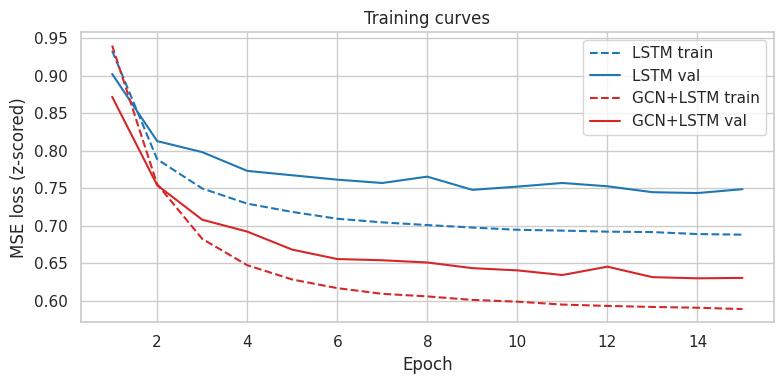

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lstm_history["epoch"], lstm_history["train_loss"], label="LSTM train", color="#1f77b4", linestyle="--")
ax.plot(lstm_history["epoch"], lstm_history["val_loss"], label="LSTM val", color="#1f77b4")
ax.plot(gcn_history["epoch"], gcn_history["train_loss"], label="GCN+LSTM train", color="#d62728", linestyle="--")
ax.plot(gcn_history["epoch"], gcn_history["val_loss"], label="GCN+LSTM val", color="#d62728")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss (z-scored)")
ax.set_title("Training curves")
ax.legend()
plt.tight_layout()
plt.show()

**Observations:**

- GCN+LSTM trains faster and reaches a lower validation loss (~0.63 vs ~0.74 for the LSTM after 15 epochs).
- Both losses are still trending down at the end - no overfitting yet, so more epochs or a bigger model could squeeze out more.
- Even a small 16-dim GCN hidden state is enough to make a clear difference.

---

<h2 class="usecase-section-header">Evaluation</h2>

<p>Score all three models on the test set across the 3 horizons (<b>1h, 3h, 6h</b>). RMSE and MAE are in <b>trips per hour</b>. MAPE uses a small floor (<code>max(|y|, 1)</code>) because plenty of stations honestly have zero pickups in some hours.</p>

<h3 class="usecase-subsection-header">Combined Results Table</h3>

<p>Stack the metrics from all three models and pivot into per-horizon RMSE and MAE tables for an easy side-by-side comparison.</p>

In [19]:
all_results = pd.concat([ha_results, lstm_results, gcn_results], ignore_index=True)
pivot_rmse = all_results.pivot(index="model", columns="horizon_h", values="RMSE").round(3)
pivot_mae = all_results.pivot(index="model", columns="horizon_h", values="MAE").round(3)

print("RMSE per horizon (trips/hour):")
print(pivot_rmse)
print("\nMAE per horizon (trips/hour):")
print(pivot_mae)
print("\nFull table:")
all_results.round(3)

RMSE per horizon (trips/hour):
horizon_h          1      3      6
model                             
GCN+LSTM       2.718  2.923  3.045
HistoricalAvg  2.669  2.673  2.671
LSTM           2.886  3.199  3.301

MAE per horizon (trips/hour):
horizon_h          1      3      6
model                             
GCN+LSTM       1.815  1.953  2.009
HistoricalAvg  1.721  1.724  1.722
LSTM           1.932  2.155  2.219

Full table:


,model,horizon_h,RMSE,MAE,MAPE%
0,HistoricalAvg,1,2.669,1.721,63.304
1,HistoricalAvg,3,2.673,1.724,63.293
2,HistoricalAvg,6,2.671,1.722,63.407
3,LSTM,1,2.886,1.932,77.346
4,LSTM,3,3.199,2.155,85.907
5,LSTM,6,3.301,2.219,88.261
6,GCN+LSTM,1,2.718,1.815,74.693
7,GCN+LSTM,3,2.923,1.953,79.426
8,GCN+LSTM,6,3.045,2.009,79.200


**Observations:**

- **HistoricalAvg wins at every horizon** (RMSE 2.669 / 2.673 / 2.671). The calendar pattern is so strong that a lookup beats both deep models on this slice.
- **GCN+LSTM is the runner-up** at h=3 and h=6 (RMSE 2.92 / 3.05), beating the plain LSTM (3.20 / 3.30) by about 8–9%.
- At h=1, GCN+LSTM is within ~2% of HistoricalAvg — the closest the deep models get.
- MAPE looks much worse for the deep models (75–88%) than for HA (~63%). That is because they sometimes predict small non-zero values where the true count is zero, and the MAPE floor blows that up.

<h3 class="usecase-subsection-header">RMSE Bar Chart</h3>

<p>Show test RMSE per horizon as a grouped bar chart, one bar per model — easier to compare than a table.</p>

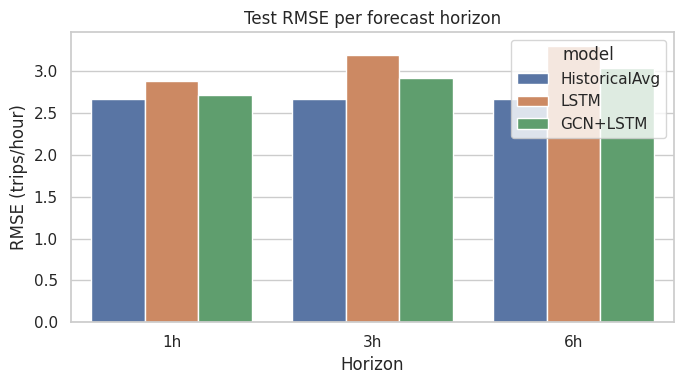

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_df = all_results.copy()
plot_df["horizon_h"] = plot_df["horizon_h"].astype(str) + "h"
sns.barplot(data=plot_df, x="horizon_h", y="RMSE", hue="model", ax=ax)
ax.set_title("Test RMSE per forecast horizon")
ax.set_xlabel("Horizon")
ax.set_ylabel("RMSE (trips/hour)")
plt.tight_layout()
plt.show()

**Observations:**

- The HistoricalAvg bar is the shortest at every horizon — it has the lowest RMSE for h=1, h=3, and h=6.
- HA's bars are all about the same height because horizon length does not change a calendar lookup.
- The deep-model bars grow taller as the horizon stretches, and GCN+LSTM is always shorter than the plain LSTM.

---

<h2 class="usecase-section-header">Visualisation and Insights</h2>

<p>Two final visualisations to make the numbers concrete: <b>predicted vs actual</b> demand at the 4 busiest stations during the <b>last 7 days</b> of the test period, and a <b>scatter plot of mean absolute error per station</b>. On that plot, bigger and redder = harder to predict.</p>

<h3 class="usecase-subsection-header">Predicted vs Actual at Top Stations</h3>

<p>Plot the 1-hour-horizon predictions from both deep models against actual pickups for the last 7 days of the test set, one panel per station for the 4 busiest stations.</p>

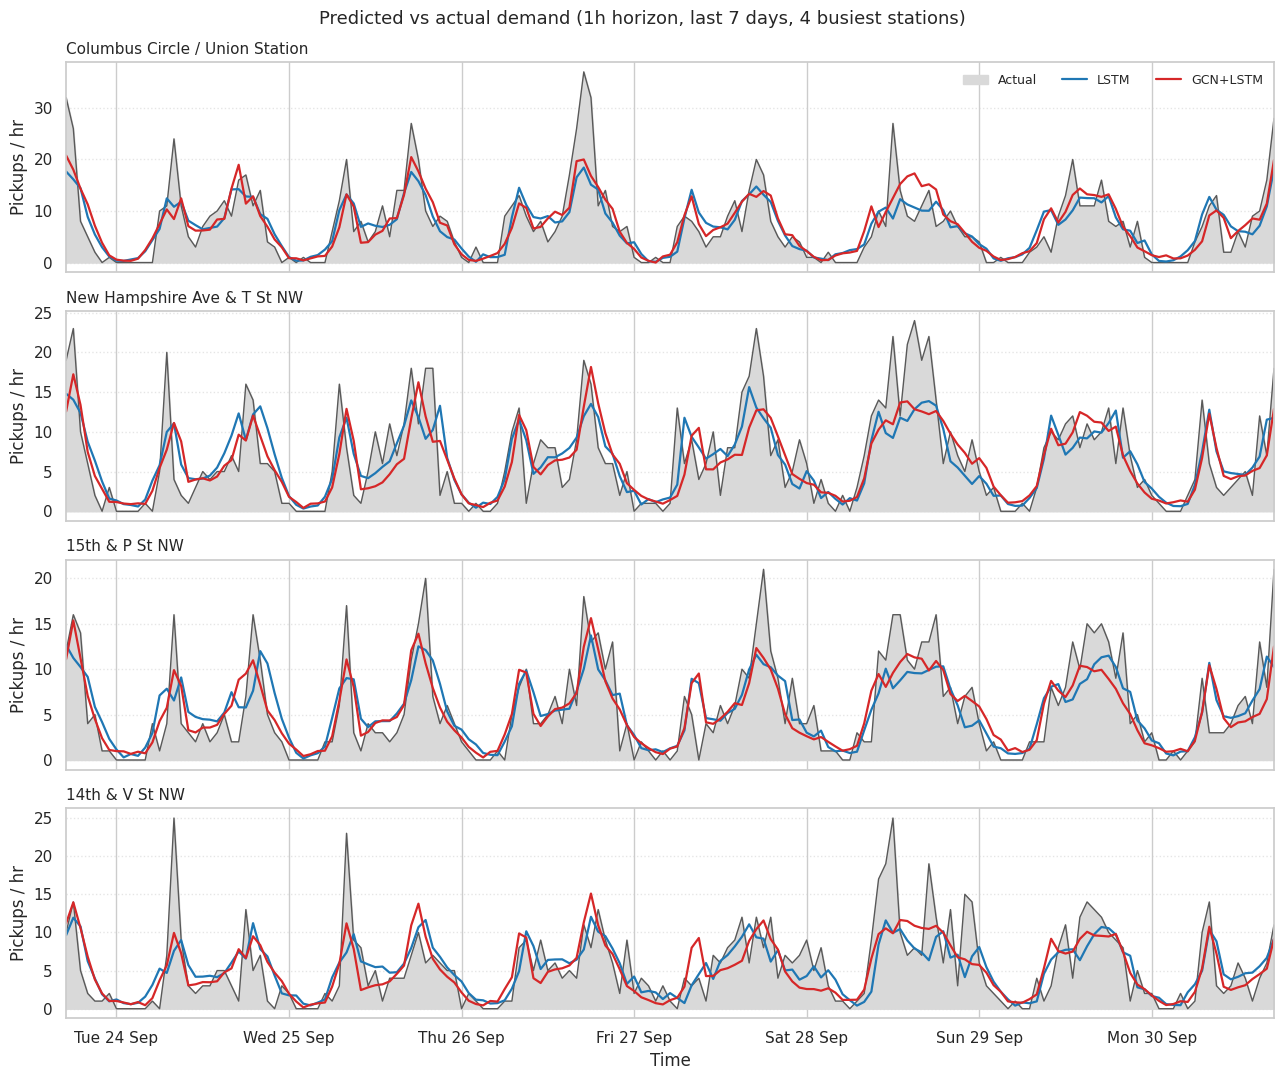

In [21]:
import matplotlib.dates as mdates

n_test_samples = gcn_pred.shape[0]
test_start_t = n_train + n_val
test_index = demand.index[test_start_t : test_start_t + n_test_samples]

PLOT_DAYS = 7
zoom_end = test_index[-1]
zoom_start = zoom_end - pd.Timedelta(days=PLOT_DAYS)
zoom_mask = (test_index >= zoom_start) & (test_index <= zoom_end)
zoom_idx = test_index[zoom_mask]

busiest_idx = np.argsort(stations["trips"].values)[::-1][:4]
fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True)

for ax, st_i in zip(axes, busiest_idx):
    actual = gcn_true[zoom_mask, 0, st_i]
    lstm_y = lstm_pred[zoom_mask, 0, st_i]
    gcn_y = gcn_pred[zoom_mask, 0, st_i]

    ax.fill_between(zoom_idx, 0, actual, color="0.85", label="Actual")
    ax.plot(zoom_idx, actual, color="0.35", linewidth=1.0)
    ax.plot(zoom_idx, lstm_y, label="LSTM", color="#1f77b4", linewidth=1.6)
    ax.plot(zoom_idx, gcn_y, label="GCN+LSTM", color="#d62728", linewidth=1.6)

    ax.set_title(stations.iloc[st_i]["name"][:60], fontsize=11, loc="left")
    ax.set_ylabel("Pickups / hr")
    ax.grid(axis="y", linestyle=":", alpha=0.5)
    ax.margins(x=0)

axes[0].legend(loc="upper right", ncol=3, fontsize=9, frameon=False)
axes[-1].xaxis.set_major_locator(mdates.DayLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b"))
axes[-1].set_xlabel("Time")

fig.suptitle(
    f"Predicted vs actual demand (1h horizon, last {PLOT_DAYS} days, 4 busiest stations)",
    fontsize=13,
)
plt.tight_layout()
plt.show()

**Observations:**

- Both deep models follow the morning + evening commute shape and the overnight dips pretty well.
- They still underestimate the sharpest commute-hour peaks — and those are exactly the moments rebalancing matters most.
- At the busiest stations, GCN+LSTM hugs the tall peaks more closely than the plain LSTM, which lines up with its lower test RMSE.

<h3 class="usecase-subsection-header">Per-Station Error Map</h3>

<p>Plot each station on a lat/lng scatter plot, colour and size each marker by its 1-hour MAE. Bigger and redder markers are stations the model has the hardest time with.</p>

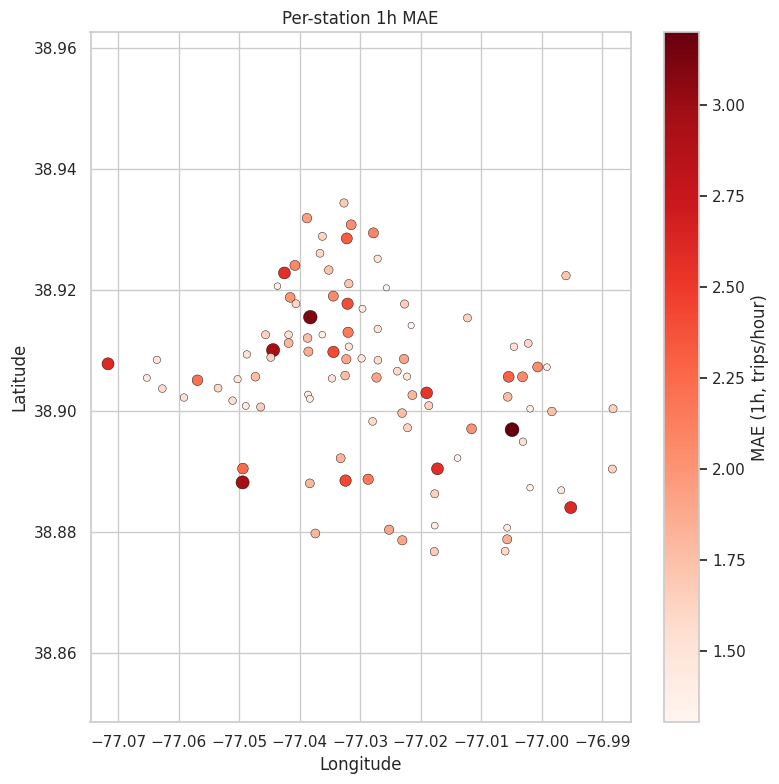

Mean MAE across stations (1h): 1.815
Top 5 hardest stations:
                                               name  trips   mae_1h
                    Columbus Circle / Union Station  30539 3.201036
                        New Hampshire Ave & T St NW  28206 3.102204
               Massachusetts Ave & Dupont Circle NW  21585 2.956405
                                   Lincoln Memorial  20078 2.952948
Eastern Market Metro / Pennsylvania Ave & 8th St SE  21987 2.612952


In [22]:
station_mae = np.abs(gcn_true[:, 0] - gcn_pred[:, 0]).mean(axis=0)
err_df = stations.assign(mae_1h=station_mae)

mae_min, mae_max = err_df["mae_1h"].min(), err_df["mae_1h"].max()
norm = (err_df["mae_1h"] - mae_min) / max(mae_max - mae_min, 1e-6)

fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(
    err_df["lng"], err_df["lat"],
    c=err_df["mae_1h"], s=20 + 80 * norm,
    cmap="Reds", edgecolor="black", linewidth=0.3,
)
plt.colorbar(sc, ax=ax, label="MAE (1h, trips/hour)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Per-station 1h MAE")
ax.set_aspect("equal", adjustable="datalim")
plt.tight_layout()
plt.show()

print("Mean MAE across stations (1h):", round(station_mae.mean(), 3))
print("Top 5 hardest stations:")
print(err_df.sort_values("mae_1h", ascending=False).head(5)[["name", "trips", "mae_1h"]].to_string(index=False))

**Observations:**

- The average MAE across all 100 stations at h=1 is **1.815 trips/hour**.
- The 5 hardest stations are all big commuting or tourist hubs: **Columbus Circle / Union Station** (MAE 3.20), **New Hampshire Ave & T St NW** (3.10), **Massachusetts Ave & Dupont Circle NW** (2.96), **Lincoln Memorial** (2.95), **Eastern Market Metro / Pennsylvania Ave & 8th St SE** (2.61).
- These are the stations the rebalancing team should watch closest — high volume, sudden bursts, often driven by events.

<h3 class="usecase-subsection-header">Insights</h3>

<ul>
<li>The simple calendar lookup (HistoricalAvg) gives the lowest error at every horizon. Bike demand is so regular week to week that just averaging past hours is hard to beat.</li>
<li>The GCN+LSTM is better than the plain LSTM at every horizon. Letting each station "see" its neighbours helps.</li>
<li>For 1-hour predictions the GCN+LSTM is almost as good as the calendar lookup. The gap grows for 3- and 6-hour predictions.</li>
<li>The hardest stations to predict are big transit hubs and tourist spots — Union Station, NH Ave &amp; T NW, Dupont Circle, Lincoln Memorial, and Eastern Market Metro. These are the ones the rebalancing team should watch most closely.</li>
<li>Easiest next improvement: also give the deep models calendar features (day of week, hour of day, holidays) so they don't have to learn the weekly pattern from raw counts.</li>
</ul>

<h3 class="usecase-subsection-header">Implications for bike redistribution</h3>

<p>Per-station, per-horizon forecasts let the team estimate the demand vs supply gap a few hours ahead and dispatch bikes before stockouts happen — prioritising stations where forecast minus current bikes is most negative.</p>

---

<h2 class="usecase-section-header">Conclusion and Future Work</h2>

<h3 class="usecase-subsection-header">Conclusion</h3>

<p>We trained a small graph + LSTM model on 6 months of Capital Bikeshare data. Adding the graph (so that each station can see its neighbours) made it more accurate than a plain LSTM at each horizon, which shows that what is happening at nearby stations does help.</p>

<p>Though the simple calendar baseline (average past pickups by day of week and hour) is still the best on this dataset. Demand for bikes is very repetitive week to week so a lookup is hard to beat. Then we would also give those calendar signals to the deep models. That is most likely to finally beat it.</p>

<h3 class="usecase-subsection-header">Limitations</h3>

<ul>
<li>Only 6 months and 100 stations to keep training fast. All 790 stations over a full year would likely help.</li>
<li>No dock capacity or current bike count is used.</li>
<li>The deep models see no explicit calendar features, which is probably why the calendar baseline still wins.</li>
</ul>

<h3 class="usecase-subsection-header">Future Work</h3>

<ul>
<li>Add calendar features (day-of-week, hour-of-day, is_holiday, sin/cos encodings) to the deep models.</li>
<li>Swap the GCN for a Graph Attention Network (GAT) so edge weights are learned.</li>
<li>Add temporal attention on top of the LSTM so the model can focus on the most useful past hours.</li>
<li>Forecast pickups and drop-offs jointly and use the net for rebalancing decisions.</li>
</ul>